# Predicting PISA 2022 Math Scores with PySpark

---

## Overview

This project builds a machine learning pipeline in PySpark to predict student math proficiency scores using data from the OECD's **Programme for International Student Assessment (PISA) 2022**. The dataset contains 588,000+ student records across 81 education systems worldwide.

Using socioeconomic, demographic, and household-level features, we train and evaluate regression models to identify the strongest predictors of math achievement.

**Data:** [OECD PISA 2022 Student Questionnaire](https://www.oecd.org/en/data/datasets/pisa-2022-database.html)

**Pipeline:**
1. Load cleaned data into PySpark
2. Exploratory data analysis
3. Feature engineering (StringIndexer → OneHotEncoder → VectorAssembler → StandardScaler)
4. Model training (Linear Regression, Random Forest)
5. Evaluation and feature importance analysis

## 1. Imports

In [1]:
# !pip install pyspark

import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Spark Session

In [2]:
spark = SparkSession.builder \
    .appName("PISA_Math_Score_Prediction") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/29 18:48:51 WARN Utils: Your hostname, Ethans-MacBook-Air-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.122 instead (on interface en0)
26/03/29 18:48:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/29 18:48:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


## 3. Data

The cleaned dataset was prepared in the pisa_data_downloader.ipynb notebook, which downloads the raw PISA 2022 SPSS file from the OECD.

In [3]:
df = spark.read.csv("pisa_2022_math_clean.csv", header=True, inferSchema=True)
df.cache()

print(f"Loaded: {df.count():,} rows x {len(df.columns)} columns")
print()
df.printSchema()

[Stage 2:=======>                                                   (1 + 7) / 8]

Loaded: 588,276 rows x 9 columns

root
 |-- country: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- mother_educ: string (nullable = true)
 |-- father_educ: string (nullable = true)
 |-- escs: double (nullable = true)
 |-- home_possessions: double (nullable = true)
 |-- ict_resources: double (nullable = true)
 |-- study_hours_homework: double (nullable = true)
 |-- math_score: double (nullable = true)



### Why PySpark?

The cleaned dataset has 588,000+ rows which is manageable in Pandas, but the full PISA student file has 1,200+ columns and exceeds 2 GB. In a larger, more expansive project, we'd also be merging student and school questionnaires across multiple PISA cycles (2000–2022), which scales into the tens of millions of rows. PySpark's ML Pipeline API lets us write preprocessing and modeling code that works identically on a laptop and a distributed cluster, which means the same codebase scales without rewriting.

## 4. Exploratory Data Analysis

In [4]:
print("Numeric Features")
df.select('escs', 'home_possessions', 'ict_resources', 'study_hours_homework', 'math_score').describe().show()

print("Top 10 Countries (by count)")
df.groupBy('country').count().orderBy(F.desc('count')).show(10)

print("Gender Split")
df.groupBy('gender').count().show()

Numeric Features
+-------+--------------------+------------------+-------------------+--------------------+------------------+
|summary|                escs|  home_possessions|      ict_resources|study_hours_homework|        math_score|
+-------+--------------------+------------------+-------------------+--------------------+------------------+
|  count|              588276|            588276|             588276|              588276|            588276|
|   mean|-0.31041488128021527|-0.441940513976434|-0.3250709160326103|  5.6142847914924285| 442.3005006000585|
| stddev|  1.1299143038491852|1.1624384584493914| 1.0711992867805396|   3.365236240979485|102.19380558286412|
|    min|             -6.8407|           -10.074|            -6.0891|                 0.0|               0.0|
|    max|                7.38|           15.2402|             5.2875|                10.0|           943.041|
+-------+--------------------+------------------+-------------------+--------------------+-------------

### Why These Features?

The features were selected based on the PISA literature and what's consistently shown to predict math achievement:

- **ESCS** — PISA's composite socioeconomic index. Every PISA cycle since 2000 identifies it as the single strongest background predictor of performance. It combines parental education, parental occupation, and home possessions into one standardized score.
- **HOMEPOS / ICTRES** — These are the component indices that feed into ESCS. Including them alongside ESCS lets the model capture non-linear relationships between specific resource dimensions and achievement that the composite might mask.
- **Parental education** — Included as a categorical feature (rather than relying solely on its contribution to ESCS) because the ISCED-level breakdowns reveal a step-function pattern that a continuous index can't capture.
- **Study hours** — Included as a control variable. PISA research consistently finds weak or null effects of self-reported study time on achievement, but omitting it would be a notable gap.
- **Country** — Absorbs education-system-level variance (curriculum, teacher quality, funding models) that student-level features can't explain.

### 4.1 Score Distribution

The PISA math scale has an OECD average of approximately 442. The left panel shows the overall distribution. T he right panel compares the top 10 highest-scoring education systems.

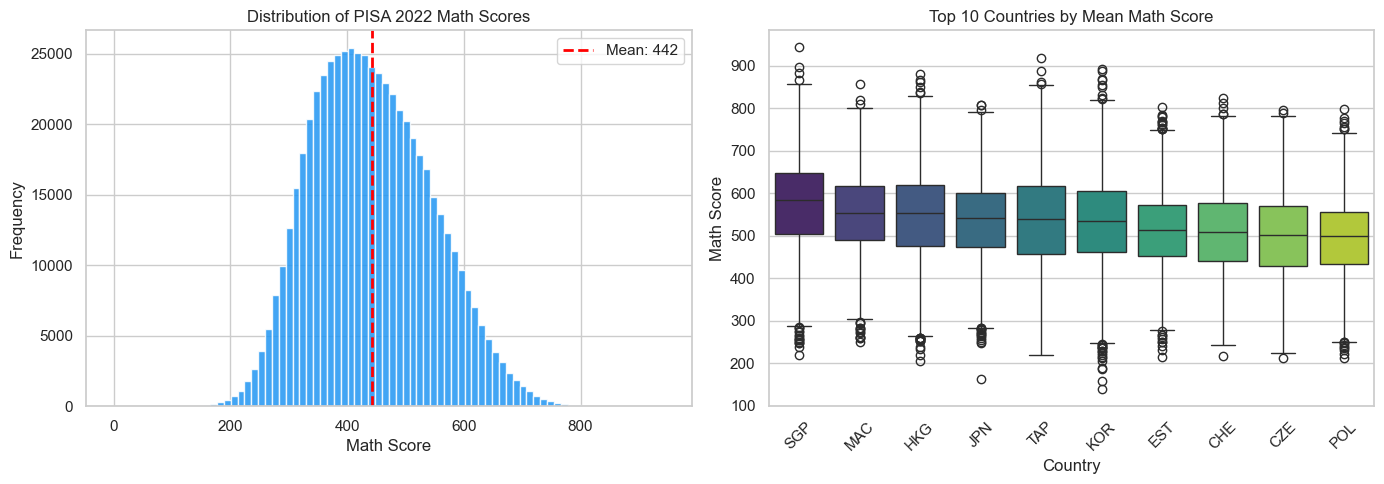

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scores_pd = df.select('math_score').toPandas()
axes[0].hist(scores_pd['math_score'], bins=80, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(scores_pd['math_score'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {scores_pd['math_score'].mean():.0f}")
axes[0].set_xlabel('Math Score'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of PISA 2022 Math Scores')
axes[0].legend()

country_scores = df.select('country', 'math_score').toPandas()
top10 = country_scores.groupby('country')['math_score'].mean().nlargest(10).index.tolist()
subset = country_scores[country_scores['country'].isin(top10)]
order = subset.groupby('country')['math_score'].mean().sort_values(ascending=False).index
sns.boxplot(data=subset, x='country', y='math_score', order=order, ax=axes[1], palette='viridis')
axes[1].set_xlabel('Country'); axes[1].set_ylabel('Math Score')
axes[1].set_title('Top 10 Countries by Mean Math Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('01_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Feature Relationships

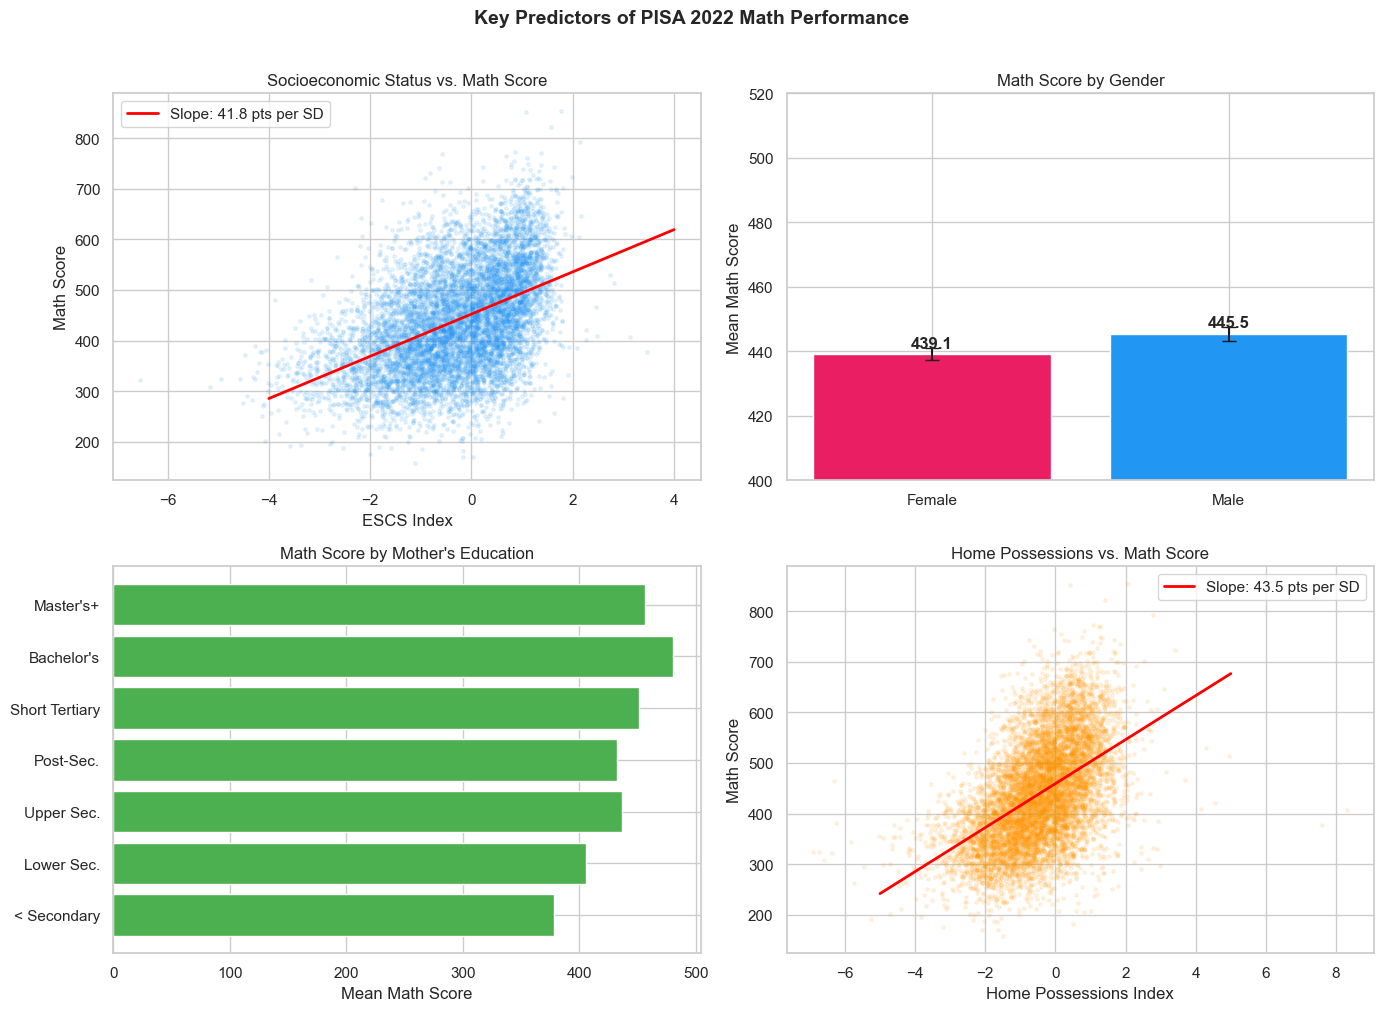

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
eda_pd = df.select('escs', 'math_score', 'gender', 'mother_educ', 'home_possessions').toPandas()

# ESCS scatter
sample = eda_pd.sample(min(8000, len(eda_pd)), random_state=42)
mask = sample['escs'].notna()
axes[0,0].scatter(sample.loc[mask, 'escs'], sample.loc[mask, 'math_score'],
                  alpha=0.1, s=6, color='#2196F3')
z = np.polyfit(sample.loc[mask, 'escs'], sample.loc[mask, 'math_score'], 1)
x_line = np.linspace(-4, 4, 100)
axes[0,0].plot(x_line, np.polyval(z, x_line), color='red', linewidth=2,
               label=f'Slope: {z[0]:.1f} pts per SD')
axes[0,0].set_xlabel('ESCS Index'); axes[0,0].set_ylabel('Math Score')
axes[0,0].set_title('Socioeconomic Status vs. Math Score')
axes[0,0].legend()

# Gender
gender_clean = eda_pd[eda_pd['gender'].isin(['Female', 'Male'])]
gender_means = gender_clean.groupby('gender')['math_score'].agg(['mean','std']).reset_index()
bars = axes[0,1].bar(gender_means['gender'], gender_means['mean'],
                      yerr=gender_means['std']/50, capsize=5,
                      color=['#E91E63','#2196F3'], edgecolor='white')
axes[0,1].set_ylabel('Mean Math Score'); axes[0,1].set_title('Math Score by Gender')
axes[0,1].set_ylim(400, 520)
for bar, val in zip(bars, gender_means['mean']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f'{val:.1f}', ha='center', fontweight='bold')

# Mother's education
educ_order = ['Below_secondary','Lower_secondary','Upper_secondary',
              'Post_secondary','Short_cycle_tertiary','Bachelors','Masters_plus']
educ_labels = ['< Secondary','Lower Sec.','Upper Sec.','Post-Sec.',
               'Short Tertiary',"Bachelor's","Master's+"]
educ_data = eda_pd[eda_pd['mother_educ'].isin(educ_order)]
educ_means = educ_data.groupby('mother_educ')['math_score'].mean().reindex(educ_order).dropna()
valid_labels = [educ_labels[educ_order.index(e)] for e in educ_means.index]
axes[1,0].barh(range(len(educ_means)), educ_means.values, color='#4CAF50', edgecolor='white')
axes[1,0].set_yticks(range(len(educ_means)))
axes[1,0].set_yticklabels(valid_labels)
axes[1,0].set_xlabel('Mean Math Score')
axes[1,0].set_title("Math Score by Mother's Education")

# Home possessions scatter
mask2 = sample['home_possessions'].notna()
axes[1,1].scatter(sample.loc[mask2, 'home_possessions'], sample.loc[mask2, 'math_score'],
                  alpha=0.1, s=6, color='#FF9800')
z2 = np.polyfit(sample.loc[mask2, 'home_possessions'], sample.loc[mask2, 'math_score'], 1)
x2 = np.linspace(-5, 5, 100)
axes[1,1].plot(x2, np.polyval(z2, x2), color='red', linewidth=2,
               label=f'Slope: {z2[0]:.1f} pts per SD')
axes[1,1].set_xlabel('Home Possessions Index'); axes[1,1].set_ylabel('Math Score')
axes[1,1].set_title('Home Possessions vs. Math Score')
axes[1,1].legend()

plt.suptitle('Key Predictors of PISA 2022 Math Performance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Correlation Matrix

ESCS and home possessions are highly correlated (r = 0.793), which is expected since both capture socioeconomic factors. Study hours show near-zero correlation with math scores. Which is consistent with the documented finding that self reported study time is a weak predictor in PISA data.

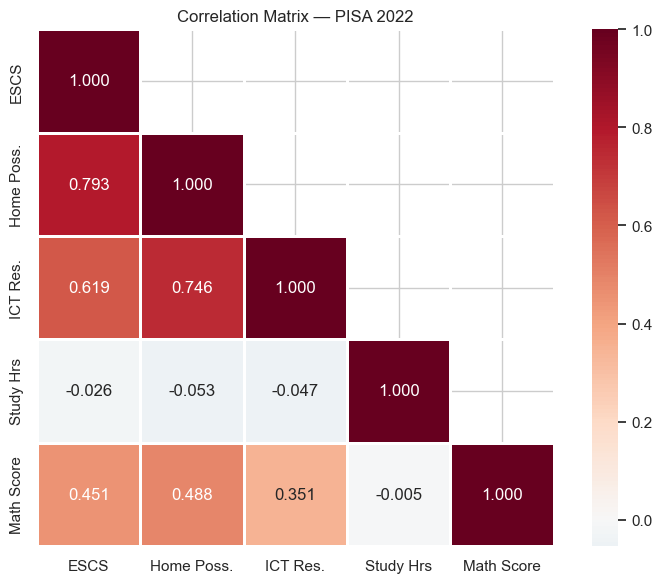

In [7]:
num_cols = ['escs', 'home_possessions', 'ict_resources', 'study_hours_homework', 'math_score']
corr_pd = df.select(num_cols).toPandas()
corr_matrix = corr_pd.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, ax=ax,
            xticklabels=['ESCS','Home Poss.','ICT Res.','Study Hrs','Math Score'],
            yticklabels=['ESCS','Home Poss.','ICT Res.','Study Hrs','Math Score'])
ax.set_title('Correlation Matrix — PISA 2022')
plt.tight_layout()
plt.savefig('03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Engineering

1. **StringIndexer** — Encode categorical variables as numeric indices
2. **OneHotEncoder** — Convert indices to binary vectors
3. **VectorAssembler** — Combine all features into a single vector column
4. **StandardScaler** — Normalize features to unit variance

Categorical features: `country`, `gender`, `mother_educ`, `father_educ`

Numeric features: `escs`, `home_possessions`, `ict_resources`, `study_hours_homework`

In [8]:
categorical_cols = ['country', 'gender', 'mother_educ', 'father_educ']
numeric_cols = ['escs', 'home_possessions', 'ict_resources', 'study_hours_homework']

stages = []
for col in categorical_cols:
    indexer = StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    encoder = OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_ohe")
    stages += [indexer, encoder]

assembler_inputs = [f"{col}_ohe" for col in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features_raw", handleInvalid="skip")
stages.append(assembler)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=False)
stages.append(scaler)

pipeline = Pipeline(stages=stages)

print(f"Pipeline: {len(stages)} stages")
for i, stage in enumerate(stages):
    name = type(stage).__name__
    detail = stage.getInputCol() if hasattr(stage, 'getInputCol') else stage.getInputCols()
    print(f"  {i+1:2d}. {name:20s} <- {detail}")

Pipeline: 10 stages
   1. StringIndexer        <- country
   2. OneHotEncoder        <- country_idx
   3. StringIndexer        <- gender
   4. OneHotEncoder        <- gender_idx
   5. StringIndexer        <- mother_educ
   6. OneHotEncoder        <- mother_educ_idx
   7. StringIndexer        <- father_educ
   8. OneHotEncoder        <- father_educ_idx
   9. VectorAssembler      <- ['country_ohe', 'gender_ohe', 'mother_educ_ohe', 'father_educ_ohe', 'escs', 'home_possessions', 'ict_resources', 'study_hours_homework']
  10. StandardScaler       <- features_raw


## 6. Train/Test Split

80/20 split. The pipeline is fitted exclusively on training data.

In [9]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print(f"Training:  {train_df.count():,}")
print(f"Test:      {test_df.count():,}")

pipeline_model = pipeline.fit(train_df)
train_transformed = pipeline_model.transform(train_df)
test_transformed = pipeline_model.transform(test_df)

print(f"\nFeature vector: {train_transformed.select('features').first()[0].size} dimensions")

Training:  470,617
Test:      117,659



Feature vector: 102 dimensions


## 7. Model Training — Linear Regression

Baseline model with L2 regularization (λ = 0.01).

In [10]:
lr = LinearRegression(featuresCol='features', labelCol='math_score',
                      maxIter=100, regParam=0.01, elasticNetParam=0.0)

print("Training Linear Regression...")
lr_model = lr.fit(train_transformed)

s = lr_model.summary
print("Training Metrics")
print(f"  RMSE: {s.rootMeanSquaredError:.2f}")
print(f"  MAE:  {s.meanAbsoluteError:.2f}")
print(f"  R²:   {s.r2:.4f}")
print(f"\nExplains {s.r2*100:.1f}% of the variance in math scores.")

Training Linear Regression...


[Stage 56:=======>                                                  (1 + 7) / 8]

Training Metrics
  RMSE: 79.36
  MAE:  62.96
  R²:   0.3968

Explains 39.7% of the variance in math scores.


## 8. Test Set Evaluation

One PISA proficiency level spans approximately 75 score points. An MAE below this threshold indicates predictions within one proficiency level on average.

In [11]:
predictions = lr_model.transform(test_transformed)

ev_rmse = RegressionEvaluator(labelCol='math_score', predictionCol='prediction', metricName='rmse')
ev_mae  = RegressionEvaluator(labelCol='math_score', predictionCol='prediction', metricName='mae')
ev_r2   = RegressionEvaluator(labelCol='math_score', predictionCol='prediction', metricName='r2')

test_rmse = ev_rmse.evaluate(predictions)
test_mae  = ev_mae.evaluate(predictions)
test_r2   = ev_r2.evaluate(predictions)

print("Test Set Performance")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  MAE:  {test_mae:.2f}")
print(f"  R²:   {test_r2:.4f}")
print(f"\nOff by ±{test_mae:.0f} pts on average (1 proficiency level ≈ 75 pts)")

Test Set Performance
  RMSE: 79.41
  MAE:  63.00
  R²:   0.3970

Off by ±63 pts on average (1 proficiency level ≈ 75 pts)


### 8.1 Model Diagnostics

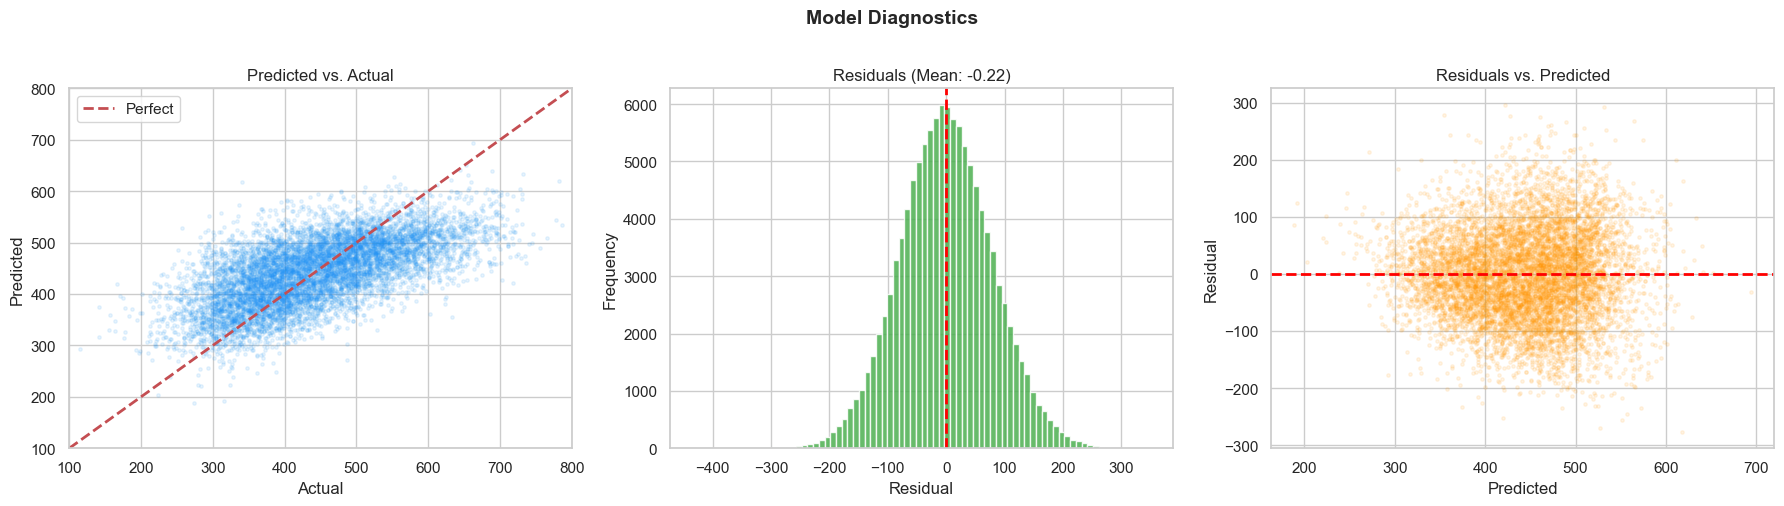

In [12]:
pred_pd = predictions.select('math_score', 'prediction').toPandas()
pred_pd['residual'] = pred_pd['math_score'] - pred_pd['prediction']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
samp = pred_pd.sample(min(8000, len(pred_pd)), random_state=42)

axes[0].scatter(samp['math_score'], samp['prediction'], alpha=0.1, s=6, color='#2196F3')
axes[0].plot([100,800],[100,800], 'r--', lw=2, label='Perfect'); axes[0].legend()
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs. Actual')
axes[0].set_xlim(100,800); axes[0].set_ylim(100,800)

axes[1].hist(pred_pd['residual'], bins=80, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residuals (Mean: {pred_pd["residual"].mean():.2f})')

axes[2].scatter(samp['prediction'], samp['residual'], alpha=0.1, s=6, color='#FF9800')
axes[2].axhline(0, color='red', linestyle='--', lw=2)
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs. Predicted')

plt.suptitle('Model Diagnostics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance

Random Forest (50 trees, max depth 8) trained to extract feature importance scores. One-hot encoded sub-features are aggregated back to their parent variable.

Training Random Forest...


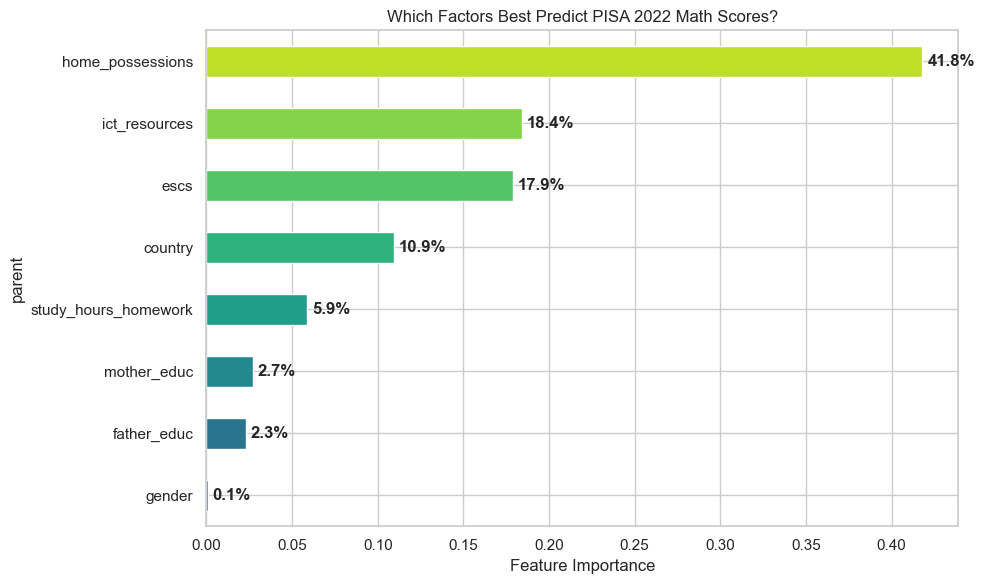


Top predictors:
  home_possessions               41.8%
  ict_resources                  18.4%
  escs                           17.9%
  country                        10.9%
  study_hours_homework           5.9%


In [13]:
rf = RandomForestRegressor(featuresCol='features', labelCol='math_score',
                          numTrees=50, maxDepth=8, seed=42)
print("Training Random Forest...")
rf_model = rf.fit(train_transformed)

importances = rf_model.featureImportances.toArray()

feature_names = []
for col in categorical_cols:
    for stage in pipeline_model.stages:
        if hasattr(stage, 'getOutputCol') and stage.getOutputCol() == f"{col}_idx":
            feature_names.extend([f"{col}={lab}" for lab in stage.labels])
            break
feature_names.extend(numeric_cols)

min_len = min(len(importances), len(feature_names))
imp_df = pd.DataFrame({'feature': feature_names[:min_len], 'importance': importances[:min_len]})
imp_df['parent'] = imp_df['feature'].apply(lambda x: x.split('=')[0])
grouped = imp_df.groupby('parent')['importance'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(grouped)))
grouped.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Which Factors Best Predict PISA 2022 Math Scores?')
total = grouped.sum()
for i, (val, name) in enumerate(zip(grouped.values, grouped.index)):
    ax.text(val + 0.003, i, f'{val/total*100:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop predictors:")
for name, val in grouped.sort_values(ascending=False).head(5).items():
    print(f"  {name:30s} {val/total*100:.1f}%")

### 9.1 Model Comparison

In [14]:
rf_preds = rf_model.transform(test_transformed)
rf_rmse = ev_rmse.evaluate(rf_preds)
rf_r2 = ev_r2.evaluate(rf_preds)

print("=== Model Comparison (Test Set) ===")
print(f"{'Model':<28} {'RMSE':>8} {'R²':>8}")
print("-" * 46)
print(f"{'Linear Regression':<28} {test_rmse:>8.2f} {test_r2:>8.4f}")
print(f"{'Random Forest (50 trees)':<28} {rf_rmse:>8.2f} {rf_r2:>8.4f}")

=== Model Comparison (Test Set) ===
Model                            RMSE       R²
----------------------------------------------
Linear Regression               79.41   0.3970
Random Forest (50 trees)        82.02   0.3569


## 10. Country-Level Prediction Accuracy

Comparing actual and predicted mean scores across the top 15 education systems to assess model calibration.

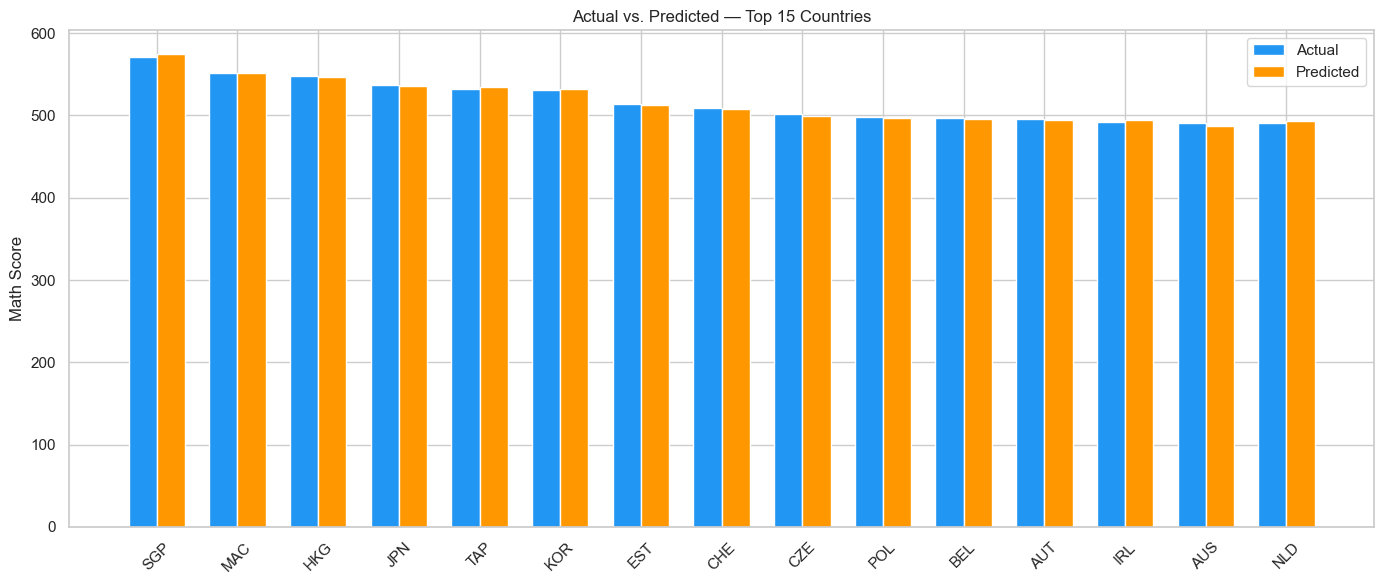

Per-country MAE:
  SGP: 76.0 pts  (n=1,393)
  MAC: 73.8 pts  (n=884)
  HKG: 81.8 pts  (n=1,097)
  JPN: 68.0 pts  (n=1,173)
  TAP: 83.4 pts  (n=1,136)
  KOR: 75.7 pts  (n=1,301)
  EST: 62.4 pts  (n=1,312)
  CHE: 67.2 pts  (n=1,288)
  CZE: 70.0 pts  (n=1,641)
  POL: 62.4 pts  (n=1,168)
  BEL: 66.9 pts  (n=1,629)
  AUT: 66.4 pts  (n=1,209)
  IRL: 56.4 pts  (n=1,072)
  AUS: 71.8 pts  (n=2,625)
  NLD: 79.9 pts  (n=950)


In [15]:
cm = (predictions
    .withColumn('abs_error', F.abs(F.col('math_score') - F.col('prediction')))
    .groupBy('country')
    .agg(F.mean('math_score').alias('actual'),
         F.mean('prediction').alias('predicted'),
         F.mean('abs_error').alias('mae'),
         F.count('*').alias('n'))
    .orderBy(F.desc('actual'))
).toPandas().head(15)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(cm))
w = 0.35
ax.bar([i-w/2 for i in x], cm['actual'], w, label='Actual', color='#2196F3', edgecolor='white')
ax.bar([i+w/2 for i in x], cm['predicted'], w, label='Predicted', color='#FF9800', edgecolor='white')
ax.set_xticks(list(x)); ax.set_xticklabels(cm['country'], rotation=45)
ax.set_ylabel('Math Score'); ax.set_title('Actual vs. Predicted — Top 15 Countries')
ax.legend()
plt.tight_layout()
plt.savefig('06_country_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Per-country MAE:")
for _, r in cm.iterrows():
    print(f"  {r['country']}: {r['mae']:.1f} pts  (n={int(r['n']):,})")

## Findings

**Model Performance:** Linear Regression achieves R² = 0.40 with MAE = 63 points predicting within one PISA proficiency level (≈ 75 pts) using only background variables. Training and test metrics are nearly identical (RMSE 79.36 vs 79.41), indicating no overfitting.

**Top Predictors of Math Achievement:**

| Rank | Feature | Importance |
|------|---------|-----------|
| 1 | Home Possessions (HOMEPOS) | 41.8% |
| 2 | ICT Resources | 18.4% |
| 3 | Socioeconomic Status (ESCS) | 17.9% |
| 4 | Country | 10.9% |
| 5 | Study Hours (Homework) | 5.9% |

**Key Takeaways:**
- Socioeconomic factors (home possessions, ICT resources, ESCS) collectively account for **78%** of predictive power, consistent with two decades of PISA research on equity gaps in education.
- Home possessions alone (41.8%) outweighs ESCS (17.9%) as a predictor.
- Country-level effects explain 10.9% of variance, reflecting systemic differences in curricula, teacher quality, and educational investment across 81 education systems.
- Parental education (mother + father combined: 5.0%) has modest independent importance, likely because its effect is already captured through ESCS and home possessions.
- Study hours show a near zero correlation with math scores (r = -0.005) and only 5.9% feature importance. Consistent with PISA literature finding that study time is a weak and unreliable predictor.
- The gender gap is approximately 6 points (Female: 439.1, Male: 445.5).

**Tools:** PySpark · PySpark ML · Pandas · Matplotlib · Seaborn · Jupyter

In [16]:
spark.stop()